# Fusemachines AI Fellowship 2026
> ## Agentic Routing with LLMs & Transformers

**Topic:** Transformers, LLMs, and Foundation Models
**File to submit:** `<your_name>_support_routing.ipynb`: must run top-to-bottom without errors.

## 0. Assignment Overview

**Scenario.** You are on the AI engineering team at **ShopAssist AI**. Before any specialized
support agent can respond to a customer, an incoming message has to be **routed** to exactly
one of 11 agents. Your job is to prototype and benchmark **two** routing strategies and
recommend one for production.

| Agent | Intents it owns |
|---|---|
| ACCOUNT | create_account, delete_account, edit_account, switch_account |
| CANCEL | check_cancellation_fee |
| CONTACT | contact_customer_service, contact_human_agent |
| DELIVERY | delivery_options |
| FEEDBACK | complaint, review |
| INVOICE | check_invoice, get_invoice |
| SUBSCRIPTION | newsletter_subscription |
| ORDER | cancel_order, change_order, place_order |
| PAYMENT | check_payment_methods, payment_issue |
| REFUND | check_refund_policy, track_refund |
| SHIPPING | change_shipping_address, set_up_shipping_address |

**Dataset.** `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — use the `category`
column directly as your 11-class target (`instruction` is the customer message).


**What you will build:**
1. **Approach 1** — fine-tune an encoder-only transformer (BERT-family) as a `[CLS]`-token classifier.
2. **Approach 2** — fine-tune a decoder-only SLM (Qwen) to *generate* the agent name as a single token, optionally with LoRA.
3. A **comparison** of both approaches on the *same* held-out test set, a **recommendation**, and a **reflection**.

**Every `# TODO` marker in this notebook is something you need to implement.** Helper functions are provided so you can focus on the modeling decisions that matter for this topic (tokenization, model setup, training configuration, evaluation, and interpreting results).

## Setup

In [3]:
# 0. Setup and Installations
!pip install -q "transformers<5.0" datasets evaluate peft accelerate trl scikit-learn matplotlib seaborn pandas
!pip install -U -q bitsandbytes
!pip install -q -U "torchao>=0.16.0"

## 1. Global Configuration

Read it carefully, since `TARGET_CATEGORIES`, `label2id`, `id2label`, and `NUM_LABELS` are used by **both** approaches below.

In [4]:
import torch
import gc
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict, ClassLabel, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, Trainer, TrainingArguments,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

RANDOM_SEED = 0
HF_DATA_ID = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"

# The 11 support agents == the 11 categories in the dataset (see Section 0 table).
TARGET_CATEGORIES = [
    'ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE',
    'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION'
]
NUM_LABELS = len(TARGET_CATEGORIES)
assert NUM_LABELS == 11, "Expected exactly 11 support agents / categories"

# If a model you pick requires authentication (gated repo), log in
# INTERACTIVELY -- never hardcode a token in a notebook you submit or share:
#
#   from huggingface_hub import login
#   login()   # prompts for a token, or reads the HF_TOKEN env var
#
# None of the candidate models below require this, so it's commented out.

Using device: cuda
Tesla T4


## 2. Helper Functions

These are given so both approaches can share identical:
- `get_metrics`: macro precision/recall/F1 + accuracy.
- `get_stratified_splits`: builds **one** train/validation/test split that Approach 1 and Approach 2 will **both** reuse (this is what guarantees "both approaches are evaluated on the same held-out test set").
- `plot_loss_curve`: plots train vs. validation loss from a `Trainer`'s `log_history`.
- `plot_confusion_matrix_heatmap`: confusion matrix heatmap for either integer or string labels.
- `measure_latency_and_memory`: times batch-size-1 inference and logs peak CUDA memory, after a short warm-up (so the first, slower CUDA-kernel-compilation call doesn't skew results).

In [5]:
def get_metrics(labels, preds):
    """
    Calculates macro-averaged evaluation metrics for classification.

    Args:
        labels: True ground truth labels.
        preds: Predicted labels from the model.

    Returns:
        A dictionary containing accuracy, precision, recall, and f1_score.
    """
    precision, recall, f1_score, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }


def get_stratified_splits(dataset_id, target_categories, seed=RANDOM_SEED,
                           train_frac=0.8, val_frac=0.1, test_frac=0.1):
    """
    Loads the Bitext dataset, filters to `target_categories`, and returns a single
    stratified train/validation/test DatasetDict
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    label2id = {c: i for i, c in enumerate(target_categories)}
    id2label = {i: c for c, i in label2id.items()}

    dataset = load_dataset(dataset_id, split="train")
    dataset = dataset.filter(lambda x: x["category"] in target_categories)
    dataset = dataset.map(lambda x: {"label": label2id[x["category"]]})
    dataset = dataset.cast_column("label", ClassLabel(names=target_categories))

    holdout_frac = val_frac + test_frac
    train_holdout = dataset.train_test_split(test_size=holdout_frac, stratify_by_column="label", seed=seed)
    val_test = train_holdout["test"].train_test_split(
        test_size=test_frac / holdout_frac, stratify_by_column="label", seed=seed
    )

    splits = DatasetDict({
        "train": train_holdout["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    })
    return splits, label2id, id2label


def plot_loss_curve(log_history, title="Training Loss"):
    """Given a HF Trainer's `trainer.state.log_history`, plot train vs. eval loss per step."""
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry.get("step", len(train_steps)))
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry.get("step", len(eval_steps)))
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
    if eval_losses:
        plt.plot(eval_steps, eval_losses, label="Validation Loss", marker="s")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion_matrix_heatmap(labels, preds, class_names, title="Confusion Matrix"):
    """Confusion matrix heatmap. Works with integer labels or category-name strings."""
    use_names = isinstance(labels[0], str)
    cm = confusion_matrix(labels, preds, labels=class_names if use_names else list(range(len(class_names))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def measure_latency_and_memory(predict_one_fn, examples, warmup=3):
    """
    Calls predict_one_fn(example) once per example (batch_size=1, matching a
    realistic single-request serving scenario). Resets CUDA peak-memory stats
    after warm-up so the very first (slow, kernel-compiling) call doesn't
    skew latency, and the reported peak memory reflects only steady-state
    inference.
    """
    examples = list(examples)
    for example in examples[:warmup]:
        _ = predict_one_fn(example)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    predictions = []
    start = time.time()
    for example in examples:
        predictions.append(predict_one_fn(example))
    end = time.time()

    avg_latency_ms = (end - start) / len(examples) * 1000
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    return avg_latency_ms, peak_mem_mb, predictions

# Approach 1: Fine-Tuning Encoder-Only Transformers

**Goal:** fine-tune one of the candidate encoders as a 11-class `[CLS]`-token classifier.

**You need to implement:**
- [ ] Tokenization of the `instruction` field
- [ ] Model + tokenizer loading (`AutoModelForSequenceClassification`, `num_labels=NUM_LABELS`)
- [ ] `compute_metrics` for the `Trainer`
- [ ] `TrainingArguments` (AdamW + linear warmup is the default optimizer/scheduler for `Trainer`)
- [ ] Single-example inference function for latency/memory measurement
- [ ] Loss curves, confusion matrix (required plots), inference latency, peak GPU memory (required to log)

**Candidate models** (pick at least one; report your best by test macro-F1):
`google-bert/bert-base-uncased`, `distilbert/distilbert-base-uncased`,
`FacebookAI/roberta-base`, `answerdotai/ModernBERT-base`

### 1. Data Loading & Preprocessing

In [6]:
# Build the ONE shared stratified split used by both Approach 1 and Approach 2.
splits, label2id, id2label = get_stratified_splits(
    dataset_id=HF_DATA_ID,
    target_categories=TARGET_CATEGORIES,
    seed=RANDOM_SEED,
    train_frac=0.8,
    val_frac=0.1,
    test_frac=0.1,
)

print(f"Train size: {len(splits['train'])} | Val size: {len(splits['validation'])} | Test size: {len(splits['test'])}")
print(splits)

README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Filter:   0%|          | 0/26872 [00:00<?, ? examples/s]

Map:   0%|          | 0/26872 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/26872 [00:00<?, ? examples/s]

Train size: 21497 | Val size: 2687 | Test size: 2688
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})


### 2. Fine-Tuning Encoder-Only Transformers

In [7]:
# Choose your encoder and load it

encoder_model_id = "distilbert/distilbert-base-uncased"

enc_tokenizer = AutoTokenizer.from_pretrained(encoder_model_id)

# Peek at how long a typical support message is (in tokens) before picking max_length
# padding every example out to the model's full context window wastes compute for no reason.
_sample_lengths = [len(enc_tokenizer.encode(t)) for t in splits["train"]["instruction"][:2000]]
print(f"Instruction token length -- mean: {np.mean(_sample_lengths):.1f}, "
      f"95th pct: {np.percentile(_sample_lengths, 95):.0f}, max: {max(_sample_lengths)}")

ENC_MAX_LEN = 64

def tokenize_function(examples):
    return enc_tokenizer(examples["instruction"], truncation=True, max_length=ENC_MAX_LEN)

enc_tokenized = splits.map(tokenize_function, batched=True)
enc_data_collator = DataCollatorWithPadding(tokenizer=enc_tokenizer)

enc_model = AutoModelForSequenceClassification.from_pretrained(
    encoder_model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
).to(device)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Instruction token length -- mean: 13.0, 95th pct: 19, max: 31


Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
def compute_metrics(eval_pred):
    """Unpack eval_pred into (logits, labels), argmax the logits (axis=-1), reuse get_metrics."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return get_metrics(labels, preds)

enc_training_args = TrainingArguments(
    output_dir="./enc_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    report_to="none",
)

enc_trainer = Trainer(
    model=enc_model,
    args=enc_training_args,
    train_dataset=enc_tokenized["train"],
    eval_dataset=enc_tokenized["validation"],
    processing_class=enc_tokenizer,
    data_collator=enc_data_collator,
    compute_metrics=compute_metrics,
)

print("Training Encoder Model...")
enc_trainer.train()


Training Encoder Model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score
1,0.005200,0.003070,0.999628,0.999697,0.999848,0.999772
2,0.001200,0.001211,0.999628,0.999697,0.999848,0.999772
3,0.000700,0.000290,1.000000,1.000000,1.000000,1.000000


TrainOutput(global_step=4032, training_loss=0.05690598379523079, metrics={'train_runtime': 198.0368, 'train_samples_per_second': 325.652, 'train_steps_per_second': 20.36, 'total_flos': 336509810574504.0, 'train_loss': 0.05690598379523079, 'epoch': 3.0})

### 3. Required Plot: Training & Validation Loss Curves

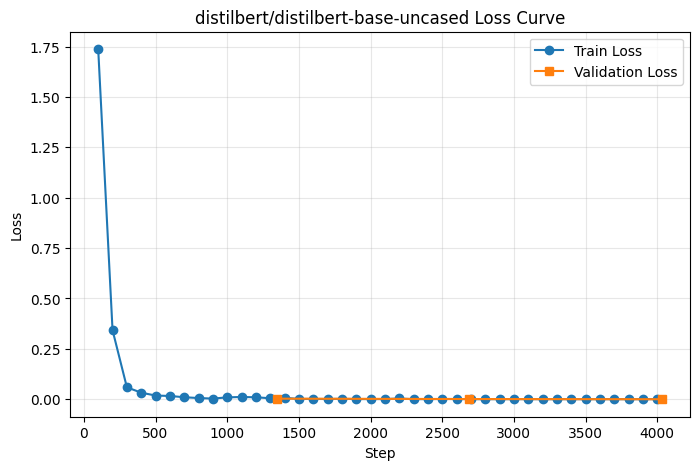

In [9]:
plot_loss_curve(enc_trainer.state.log_history, title=f"{encoder_model_id} Loss Curve")

### 4. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Write a **single-example** prediction function (batch size 1 -- this simulates a real routing
request) and feed it to `measure_latency_and_memory` together with `splits["test"]`.

In [10]:
def predict_one_encoder(example):
    """Tokenize a single instruction, run a forward pass, return the argmax label id."""
    inputs = enc_tokenizer(
        example["instruction"], return_tensors="pt", truncation=True, max_length=ENC_MAX_LEN
    ).to(device)
    with torch.no_grad():
        logits = enc_model(**inputs).logits
    return int(torch.argmax(logits, dim=-1).item())

enc_model.eval()
enc_latency, enc_peak_mem, enc_predictions = measure_latency_and_memory(
    predict_one_encoder, splits["test"]
)
enc_labels = splits["test"]["label"]

enc_metric_dict = get_metrics(enc_labels, enc_predictions)
enc_acc, enc_prec, enc_rec, enc_f1 = (enc_metric_dict["accuracy"], enc_metric_dict["precision"],
                                       enc_metric_dict["recall"], enc_metric_dict["f1_score"])

print(f"Encoder Macro-F1: {enc_f1:.4f}")
print(f"Encoder Latency: {enc_latency:.2f} ms/query")
print(f"Encoder Peak Memory: {enc_peak_mem:.2f} MB")


Encoder Macro-F1: 0.9997
Encoder Latency: 4.54 ms/query
Encoder Peak Memory: 787.58 MB


### 5. Required Plot: Confusion Matrix

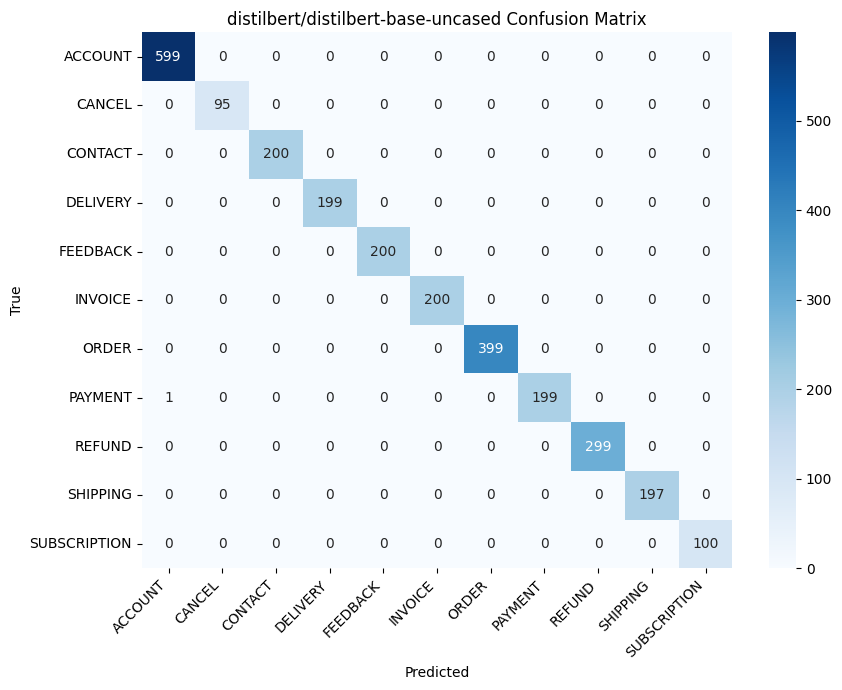

In [11]:
plot_confusion_matrix_heatmap(enc_labels, enc_predictions, TARGET_CATEGORIES,
                               title=f"{encoder_model_id} Confusion Matrix")


# Approach 2: Fine-Tuning Decoder-Only SLM (with / without LoRA)

**Goal:** treat routing as text generation; format each example as an instruction/response pair where the "response" is just the agent name (e.g. `REFUND`), then fine-tune a small decoder-only LM to produce it.

**You need to implement:**
- [ ] Model + tokenizer loading
- [ ] Instruction-formatting function (`format_example`) using a chat template
- [ ] Output parsing (`get_decoder_predictions`) that turns a raw generation into a clean label
- [ ] Tokenization for training
- [ ] LoRA config (or `USE_LORA=False` for full fine-tuning) + `TrainingArguments` + `SFTTrainer`
- [ ] Loss curves, confusion matrix, inference latency, peak GPU memory (same requirements as Approach 1)

**Candidate models:** `Qwen/Qwen2.5-0.5B-Instruct`, `Qwen/Qwen2.5-1.5B-Instruct`

> **GPU memory note:** if you hit memory limits on a free-tier GPU (Colab T4, ~15 GB), use LoRA/QLoRA via `peft` (and consider 4-bit loading via `bitsandbytes`).

### 1. Model & Tokenizer Setup

In [12]:
# TOD: choose your decoder model id
# If a candidate model is gated, authenticate INTERACTIVELY -- never hardcode
# a token in a notebook you submit or share:
#   from huggingface_hub import login; login()

decoder_model_id = "Qwen/Qwen2.5-0.5B-Instruct"
USE_LORA = True

dec_tokenizer = AutoTokenizer.from_pretrained(decoder_model_id, trust_remote_code=True)
# Some causal LMs ship without a pad token
# set one if missing.
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

if USE_LORA:
    # QLoRA: load the base model in 4-bit (bitsandbytes) and only train LoRA adapters
    # on top. This is what keeps even the 4B candidate inside a free-tier T4's ~15GB

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
    )
    dec_model = prepare_model_for_kbit_training(dec_model)
else:
    # Full fine-tuning: no quantization.
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, dtype=compute_dtype, device_map="auto", trust_remote_code=True,
    )

dec_model.config.use_cache = False   # required before training with gradient checkpointing


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

### 2. Loading & Formatting the Dataset

Reuse the **same** `splits` `DatasetDict` built in Approach 1's Data Loading step -- do **not**
call `load_dataset` again here. This is what keeps the two approaches' test sets identical.

In [13]:
print(splits)
print(splits["train"][0])

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})
{'flags': 'BCLW', 'instruction': 'I want to retrieve the damn key of my user, I need help', 'category': 'ACCOUNT', 'intent': 'recover_password', 'response': "No worries at all! I'm here to provide the necessary assistance to retrieve the key of your user account. Let's tackle this together and get you back on track!", 'label': 0}


In [14]:
SYS_PROMPT = (
    "You are an AI assistant trained for text classification; given any user "
    f"query, choose the single closest category from this fixed set: {TARGET_CATEGORIES}; "
    "output only the category name as the final answer without explanation or extra words."
)

def build_prompt(instruction_text):
    """Render the system + user turns with the model's own chat template."""
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": instruction_text},
    ]
    return dec_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def format_example(example):
    """
    1. Build the chat-templated prompt (system + user turn).
    2. The target is example["category"]
    3. Append the EOS token after the label so the model learns *where to stop*
       generating during training (otherwise it may past the label).
    4. Return {"input_text": prompt + target + eos}.
    """
    prompt = build_prompt(example["instruction"])
    target = example["category"]

    return {"input_text": prompt + target + dec_tokenizer.eos_token}

# Apply it across every split, keeping the original instruction text around
formatted_splits = splits.map(
    lambda ex: {**format_example(ex), "original_text": ex["instruction"]}
)


Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

### 3. Baseline Check: Zero-Shot Inference (Before Fine-Tuning)

In [15]:
# Given: greedy-decodes up to max_new_tokens tokens (a label is one word, so 5 is generous headroom).
def get_outputs(model, inputs, max_new_tokens=5):
    return model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        eos_token_id=dec_tokenizer.eos_token_id,
        pad_token_id=dec_tokenizer.pad_token_id,
        do_sample=False,
    )

def normalize_decoder_output(text, valid_categories=None):
    """Lowercase + strip everything but letters, then snap to a known category if the
    raw text contains one as a substring (handles the model echoing extra words/punctuation
    around the label). Falls back to the cleaned string, which will simply score as an
    incorrect prediction rather than crash the metric computation."""
    valid_categories = valid_categories or [c.lower() for c in TARGET_CATEGORIES]
    cleaned = re.sub(r"[^a-z]", "", text.lower())
    for cat in valid_categories:
        if cat in cleaned:
            return cat
    return cleaned

def get_decoder_predictions(dataset, model):
    """For every row: rebuild the chat prompt from row["original_text"], generate,
    decode only the newly-generated tokens, and normalise. Returns (labels, predictions),
    both lists of lowercased strings."""
    labels, predictions = [], []
    for row in dataset:
        prompt = build_prompt(row["original_text"])
        inputs = dec_tokenizer(prompt, return_tensors="pt").to(model.device)
        output_ids = get_outputs(model, inputs)
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
        predictions.append(normalize_decoder_output(decoded))
        labels.append(row["category"].lower())
    return labels, predictions

dec_labels, dec_preds = get_decoder_predictions(formatted_splits["test"], dec_model)
print("Zero-shot (pre-fine-tuning) baseline:", get_metrics(dec_labels, dec_preds))


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Zero-shot (pre-fine-tuning) baseline: {'accuracy': 0.2845982142857143, 'precision': 0.040901111861599684, 'recall': 0.0276580995040998, 'f1_score': 0.027477443948536198}


### 4. Tokenization for Training

In [16]:
_dec_lengths = [len(dec_tokenizer.encode(t)) for t in formatted_splits["train"]["input_text"][:1000]]
print(f"Formatted prompt+label token length -- mean: {np.mean(_dec_lengths):.1f}, "
      f"95th pct: {np.percentile(_dec_lengths, 95):.0f}, max: {max(_dec_lengths)}")

DEC_MAX_LEN = 160

def tokenize_function(examples):
    """Tokenize examples["input_text"] with truncation to a fixed max_length."""
    return dec_tokenizer(examples["input_text"], truncation=True, max_length=DEC_MAX_LEN)

dec_tokenized = formatted_splits.map(tokenize_function, batched=True)


Formatted prompt+label token length -- mean: 106.7, 95th pct: 112, max: 117


Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

### 5. LoRA Config & Training Arguments

In [20]:
peft_config = None
if USE_LORA:
    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules="all-linear",
    )

dec_train_args = TrainingArguments(
    output_dir=f"{decoder_model_id.split('/')[-1]}-router-finetuned/",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    max_grad_norm=0.1,
    num_train_epochs=2,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_strategy="steps",
    logging_steps=10,
    eval_strategy="steps",     # required so eval_loss appears in log_history for the loss-curve plot
    eval_steps=50,
    save_strategy="steps",
    save_steps=30,
    report_to="none",
)


### 6. Model Training

In [21]:
## Supervised Fine-Tuning (SFT)
dec_trainer = SFTTrainer(
    model=dec_model,
    train_dataset=dec_tokenized["train"],
    eval_dataset=dec_tokenized["validation"],
    peft_config=peft_config,
    args=dec_train_args,
)

print("Training Decoder Model...")
dec_trainer.train()


Training Decoder Model...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,0.301000,0.266443,0.282077,341661.000000,0.944468
100,0.182100,0.179294,0.177545,683272.000000,0.953305
150,0.166400,0.169105,0.182380,1024460.000000,0.952540
200,0.163700,0.161359,0.172955,1365920.000000,0.954893
250,0.151000,0.157813,0.159174,1707427.000000,0.955488
300,0.156000,0.153760,0.159043,2049200.000000,0.956207
350,0.141600,0.151558,0.148906,2389908.000000,0.956257
400,0.141900,0.150450,0.145934,2731295.000000,0.956591
450,0.144600,0.148950,0.148070,3072856.000000,0.956500
500,0.145500,0.147557,0.147547,3414460.000000,0.957169


TrainOutput(global_step=672, training_loss=0.24444906417990014, metrics={'train_runtime': 10729.9912, 'train_samples_per_second': 4.007, 'train_steps_per_second': 0.063, 'total_flos': 1.05410304129408e+16, 'train_loss': 0.24444906417990014, 'entropy': 0.14497027965262532, 'num_tokens': 4588666.0, 'mean_token_accuracy': 0.9582243598997593, 'epoch': 2.0})

### 7. Required Plot: Training & Validation Loss Curves

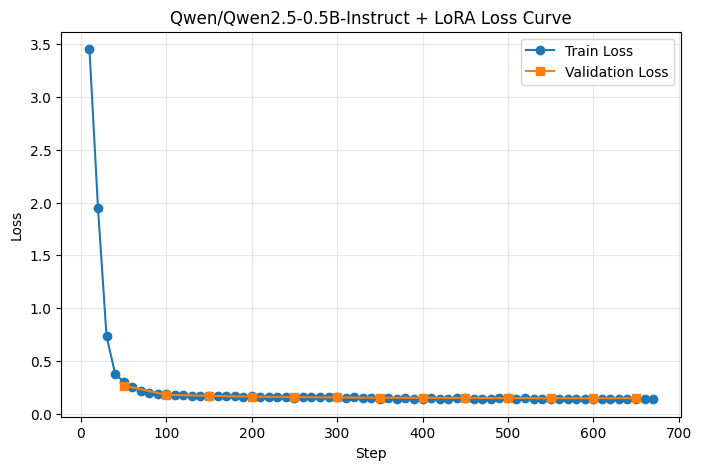

In [22]:
plot_loss_curve(dec_trainer.state.log_history,
                 title=f"{decoder_model_id}{' + LoRA' if USE_LORA else ''} Loss Curve")


### 8. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Reuse `get_decoder_predictions`, but now pass `dec_trainer.model` (the fine-tuned weights). For latency/memory, write a single-example version and pass it to `measure_latency_and_memory`, just like you did for the encoder.

In [23]:
# Evaluate the FINE-TUNED decoder on the held-out test set
def predict_one_decoder(example):
    """Single-example version of get_decoder_predictions's inner loop"""
    prompt = build_prompt(example["original_text"])
    inputs = dec_tokenizer(prompt, return_tensors="pt").to(dec_trainer.model.device)
    output_ids = get_outputs(dec_trainer.model, inputs)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
    return normalize_decoder_output(decoded)

dec_trainer.model.eval()
dec_latency, dec_peak_mem, dec_predictions = measure_latency_and_memory(
    predict_one_decoder, list(formatted_splits["test"])
)
dec_labels = [ex["category"].lower() for ex in formatted_splits["test"]]

dec_metric_dict = get_metrics(dec_labels, dec_predictions)
dec_acc, dec_prec, dec_rec, dec_f1 = (dec_metric_dict["accuracy"], dec_metric_dict["precision"],
                                       dec_metric_dict["recall"], dec_metric_dict["f1_score"])
print(dec_metric_dict)
print(f"Decoder Latency: {dec_latency:.2f} ms/query")
print(f"Decoder Peak Memory: {dec_peak_mem:.2f} MB")


{'accuracy': 0.9992559523809523, 'precision': 0.999317612212349, 'recall': 0.999317612212349, 'f1_score': 0.999317612212349}
Decoder Latency: 285.99 ms/query
Decoder Peak Memory: 1690.81 MB


### 9. Required Plot: Confusion Matrix

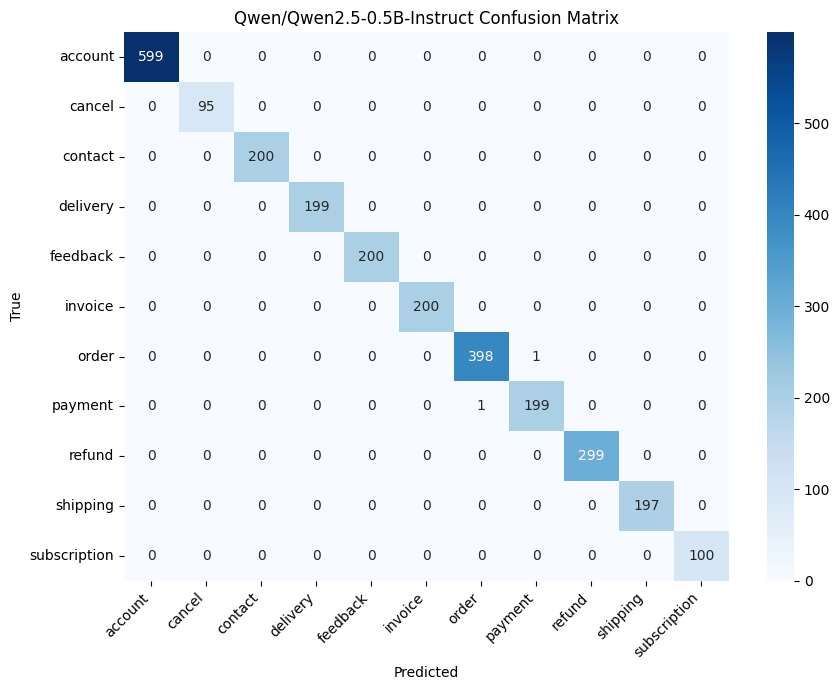

In [24]:
plot_confusion_matrix_heatmap(dec_labels, dec_predictions,
                               [c.lower() for c in TARGET_CATEGORIES],
                               title=f"{decoder_model_id} Confusion Matrix")


## 7. Comparison

Both cells below are given (pure plotting/table), they assume the variable names
used throughout this notebook (`enc_*` / `dec_*`). If you renamed anything,update the references accordingly.

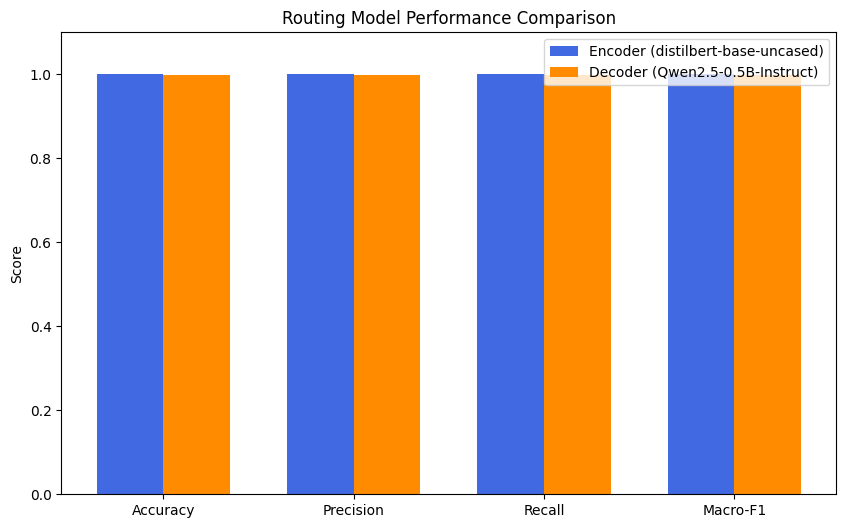

In [25]:
# Comparison bar chart
metrics_names = ["Accuracy", "Precision", "Recall", "Macro-F1"]
enc_scores = [enc_acc, enc_prec, enc_rec, enc_f1]
dec_scores = [dec_acc, dec_prec, dec_rec, dec_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, enc_scores, width, label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
ax.bar(x + width/2, dec_scores, width, label=f"Decoder ({decoder_model_id.split('/')[-1]})", color="darkorange")
ax.set_ylabel("Score")
ax.set_title("Routing Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
plt.ylim(0, 1.1)
plt.show()

In [26]:
# Dedicated comparison table with measured values
# fill in by running the cells above
comparison_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "Macro-F1", "Accuracy",
               "Peak GPU Memory (MB)", "Inference Latency (ms/query)"],
    f"Encoder ({encoder_model_id})": [enc_prec, enc_rec, enc_f1, enc_acc, enc_peak_mem, enc_latency],
    f"Decoder SLM ({decoder_model_id}{' + LoRA' if USE_LORA else ''})":
        [dec_prec, dec_rec, dec_f1, dec_acc, dec_peak_mem, dec_latency],
})
comparison_table

,Metric,Encoder (distilbert/distilbert-base-uncased),Decoder SLM (Qwen/Qwen2.5-0.5B-Instruct + LoRA)
0,Precision,0.999848,0.999318
1,Recall,0.999545,0.999318
2,Macro-F1,0.999696,0.999318
3,Accuracy,0.999628,0.999256
4,Peak GPU Memory (MB),787.582520,1690.807129
5,Inference Latency (ms/query),4.543949,285.987830


## 8. Recommendation
**To: Engineering Lead, ShopAssist AI**

I recommend deploying the encoder-only approach (fine-tuned DistilBERT) for production routing.On our held-out test set of 2,688 examples, DistilBERT reached a macro-F1 of 0.9997, compared to 0.9993 for the fine-tuned Qwen2.5-0.5B decoder with LoRA. The two models are essentially tied on accuracy, so the deciding factor is cost. DistilBERT's inference latency is 4.54 ms per query,
compared to 285.99 ms per query for the decoder, which is about 63 times faster. Peak GPU memory is also lower for DistilBERT, at 787.58 MB versus 1690.81 MB for the decoder, roughly half. At production volume, this latency and memory gap means significantly lower serving cost and higher throughput per GPU, with no real drop in accuracy.

The main production risk with DistilBERT is that its near-perfect test score is partly a result of the Bitext dataset's templated, synthetic phrasing. Real customer messages will likely be noisier. The model also has no reject option: it always assigns one of the 11 labels with full confidence, even for input that does not belong to any category, such as chit-chat or unusual phrasing. To monitor this, I would log the softmax confidence of every prediction and route
low-confidence cases to human review, track the distribution of predicted categories in production against the training-time distribution to catch drift, and periodically sample live traffic for manual audit.

## 9. Reflection

### Q1: On what transfers from pretraining
Pretraining gives both DistilBERT and Qwen2.5-0.5B a general understanding of English syntax and meaning, learned from large amounts of unlabeled text. For example, both models already know that words like "refund," "money back," and "charged twice" are related, or that "parcel," "delivery," and "shipment" belong to the same general topic. Neither model had ever seen our specific 11-agent taxonomy before, so fine-tuning had to teach the mapping from that general language understanding onto these specific categories. This gap shows clearly in the numbers. Qwen's zero-shot accuracy, before any fine-tuning, was only 0.285, with a macro-F1 of just 0.027, barely better than random guessing across 11 classes. After two epochs of fine-tuning, accuracy rose to 0.999. For DistilBERT, fine-tuning also had to build an entire classification head from scratch, since the newly initialized classifier and pre-classifier weights confirmed the base model had no existing output layer for any specific label set. For the decoder, fine-tuning had a narrower job: teach the model to stop treating the prompt as an open conversation and instead output exactly one category name and then stop. This is reflected in the 95.8 percent mean token accuracy reached on that single output token by the end of training.

### Q2: On Handling Chit-Chat Queries
The message "Hey! How's it going?" does not match any real intent among the 11 agents. DistilBERT has no "none of the above" option built in. Its softmax output always spreads probability across all 11 labels, so it will confidently assign the message to whichever category looks least different in its learned representation. This happens silently and incorrectly, with no signal to the system that something is wrong. The decoder-based Qwen model can in principle fail more gracefully, since it generates text rather than being forced into a fixed softmax over classes. An unusual input could produce an output that does not match any valid category, which at least gives an implicit signal that the model is unsure. In practice, though, our fine-tuning trained Qwen specifically to always output a single clean category name, which is exactly what led to the 95.8 percent token accuracy, so after fine-tuning it will likely also just guess a category most of the time. This mostly removes the theoretical advantage. For a production system, I would add a twelfth category such as OTHER or CHITCHAT, with representative greeting and small-talk examples in training, and pair it with a confidence threshold. This could be the maximum softmax score for DistilBERT, or an output-validity check for Qwen, so that any message falling below the threshold is routed to a generic fallback response instead of a specialized agent.